# XAI localization (positive-only occlusion): occlusion importance vs. native attention, against ground truth

This notebook is a standalone variant of `xai_localization.ipynb`. It runs the
exact same pipeline -- HPO for every `sliceheads` classification head, then
leave-one-out occlusion importance and native attention scored against real
per-slice ground-truth annotations -- with **one deliberate change**: the
signal used for the *occlusion* localization metrics (AUROC, P@K) is not
`sliceheads.explain`'s `importance` (`abs(signed_importance)`, which weighs a
slice equally whether occluding it raised or lowered the model's confidence).
Instead, it's a **positive-only** transform of the same underlying
`signed_importance` this notebook computes:

```
I_plus[k] = max(signed_importance[k], 0) / (sum_j max(signed_importance[j], 0) + epsilon)
```

with `epsilon = 1e-9`. This keeps only slices whose occlusion *lowered* the
positive-class probability -- the slices that were actually supporting the
positive prediction -- and zeroes out every slice whose occlusion *raised* it,
rather than ranking both directions of evidence on the same scale.

**Native attention (ABMIL / Gated-ABMIL / DSMIL) and DSMIL's instance stream
are left completely unchanged** -- this transform applies only to the
occlusion signal.

**You will:** load `hd5_with_mask_vector.h5` (which carries `important_slices`
ground-truth annotations for 50 test studies), run HPO for every head using
`notebooks/experiment.yaml`, compute occlusion importance and native attention
for those 50 studies, derive the positive-only occlusion signal from
`signed_importance`, save every XAI output (including the positive-only
signal as a supplementary file) through the package's own persistence API,
and rank every head/signal by how well it localizes the true important
slices (AUROC, Precision@K, and -- for attention only -- how much attention
mass concentrates on the true slices vs. chance).

This notebook is fully self-contained: it does not read any output of
`xai_localization.ipynb`, and writes to its own `xai_positive_only_*`
output paths so the two notebooks' results never collide.


## Installation

Install the released package:


In [1]:
# Released version:
# %pip install sliceheads
# For local development instead, from the repo root:
# %pip install -e .


## Imports

Standard libs first, then the package's real public API: `EmbedStore` +
`validate_h5` (Module 1), `load_config` + `run_hpo` (Module 4), `compute_metrics`
(Module 3), `compute_importance_dataset` (Module 5, the XAI module), and
`save_results` (Module 6) for persisting every XAI output file. The
positive-only occlusion transform is computed locally in this notebook, from
the package's `signed_importance` output -- it is not part of the
`sliceheads.explain` public API.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import roc_auc_score

from sliceheads.store import EmbedStore, validate_h5
from sliceheads.config import load_config
from sliceheads.hpo import run_hpo
from sliceheads.metrics import compute_metrics
from sliceheads.explain import compute_importance_dataset
from sliceheads.results import save_results


## Configuration (ALL variables here)

Everything the notebook depends on is set in this one cell.
`notebooks/experiment.yaml` supplies the per-head hyperparameter grids, search
strategy, and selection metric; `H5_PATH` is overridden to point at
`hd5_with_mask_vector.h5` (the file with `important_slices` ground truth), one
level up from this notebook. `POS_ONLY_EPSILON` is the denominator epsilon
for the positive-only occlusion transform introduced in Step 5c below.


In [3]:
# ---- Everything the notebook depends on is set here ----
EXPERIMENT_YAML_PATH = "experiment.yaml"      # per-head hyperparameter grids + run config
H5_PATH = "../hd5_with_mask_vector.h5"        # this run's input store (overrides the YAML's own data.h5_path)

RESULTS_DIR = "xai_positive_only_results"          # sliceheads.results.save_results() output (Module 6)
RESULTS_TABLE_CSV = "xai_positive_only_results_table.csv"
PLOT_PATH = "xai_positive_only_auroc.png"
EXAMPLE_PLOT_PATH = "xai_positive_only_example_study.png"

N_BOOTSTRAPS = 2000     # study-level bootstrap resamples for every aggregated metric (existing sliceheads convention)
CI_LEVEL = 0.95

POS_ONLY_EPSILON = 1e-9     # epsilon in I_plus[k] = max(signed[k], 0) / (sum_j max(signed[j], 0) + epsilon)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

EXPERIMENT_CONFIG = load_config(EXPERIMENT_YAML_PATH)     # validates schema (Module 4)
EXPERIMENT_CONFIG["data"]["h5_path"] = H5_PATH
EXPERIMENT_CONFIG["training"]["device"] = DEVICE

RANDOM_SEED = EXPERIMENT_CONFIG["training"]["random_seed"]   # <- change in experiment.yaml's training.random_seed, not here.
                                                               # Every head is fit once, at this single seed -- for
                                                               # DSMIL specifically, its dual-stream training (the hard
                                                               # argmax "critical instance" selection in _DSMILNet) is
                                                               # far more seed-sensitive than the other heads' smooth
                                                               # attention, so a different seed can noticeably change
                                                               # DSMIL's occlusion/attention localization numbers below
                                                               # even though bag-level ROC-AUC barely moves.
SELECTION_METRIC = EXPERIMENT_CONFIG["training"]["selection_metric"]
SEARCH_STRATEGY = EXPERIMENT_CONFIG["search_strategy"]

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print(f"device           : {DEVICE}")
print(f"H5_PATH          : {H5_PATH}")
print(f"random_seed      : {RANDOM_SEED}")
print(f"selection_metric : {SELECTION_METRIC}")
print(f"search_strategy  : {SEARCH_STRATEGY}")
print(f"pos_only_epsilon : {POS_ONLY_EPSILON}")


device           : cuda
H5_PATH          : ../hd5_with_mask_vector.h5
random_seed      : 42
selection_metric : roc_auc
search_strategy  : grid
pos_only_epsilon : 1e-09


## Input format

`H5_PATH` is an HDF5 store with one group per sample, written by
`sliceheads.store.EmbedStore`:

```
hd5_with_mask_vector.h5
 ├── study_0001
 │    ├── embeddings: [num_slices, embedding_dim]   # e.g. [43, 768]
 │    ├── important_slices: [num_slices] or [0]     # binary GT, empty when not annotated
 │    └── attrs: label, split
 └── ...
```

- **Source:** MosMedData-derived demo CT dataset, DINOv3 slice embeddings.
- **Labels:** binary — 0/1 diagnosis label, `split` ∈ {train, val, test}.
- **Split:** this file already carries a single train/val/test partition as a
  per-sample attribute. This notebook uses that split as-is — no re-splitting,
  no k-fold, no nested CV (see `05_nested_cross_validation.ipynb` for that).
- **Ground truth:** `important_slices` is a binary array the same length as
  `embeddings` (1 = radiologist-annotated important slice). It's empty (`[0]`)
  for most samples but fully populated for exactly 50 `test`-split studies —
  those 50 are this notebook's evaluation set for slice-level localization.


## Step 1 — Validate and load the single existing split

`validate_h5` checks the schema; `EmbedStore.load_split` returns one
variable-length `[N_i, D]` array per sample, plus labels and sample IDs. We
load `train` / `val` / `test` exactly as stored — this file's splits are used
for HPO and evaluation with no re-shuffling.


In [4]:
validate_h5(H5_PATH)
print("Validation passed ✓")

store = EmbedStore(H5_PATH)
emb_train, y_train, ids_train = store.load_split("train")
emb_val,   y_val,   ids_val   = store.load_split("val")
emb_test,  y_test,  ids_test  = store.load_split("test")

embedding_dim = emb_train[0].shape[1]

print(f"train: {len(emb_train)}  val: {len(emb_val)}  test: {len(emb_test)}  embedding_dim: {embedding_dim}")


Validation passed ✓


train: 637  val: 211  test: 215  embedding_dim: 768


## Step 2 — Training-set mean embedding

`loo_importance` (Module 5) replaces one slice at a time with the dataset
training mean embedding. `EmbedStore.mean_embedding()` reads it from a
root-level HDF5 attribute if present; this particular file predates that
attribute, so we fall back to computing it directly from the loaded train
split (the same computation `EmbedStore.compute_and_write_mean_embedding()`
performs).


In [5]:
mean_embedding = store.mean_embedding()
if mean_embedding is None:
    mean_embedding = np.concatenate(emb_train, axis=0).mean(axis=0).astype(np.float32)
    print("No 'mean_embedding' attribute in this file -- computed from the train split instead.")

print("mean_embedding shape:", mean_embedding.shape)


No 'mean_embedding' attribute in this file -- computed from the train split instead.
mean_embedding shape: (768,)


## Step 3 — HPO for every head (`sliceheads.hpo.run_hpo`)

For every enabled head in `experiment.yaml`, `run_hpo` grid/random-searches
its hyperparameters on `train`, selects by validation ROC-AUC, and returns the
best fitted head. We then score that head once on the held-out `test` split
with `compute_metrics` for context before moving on to explainability.


In [6]:
fitted_heads = {}
best_params_per_head = {}
metrics_per_head = {}
predictions_per_head = {}

for head_name, head_cfg in EXPERIMENT_CONFIG["heads"].items():
    if not head_cfg.get("enabled", True):
        continue

    result = run_hpo(
        head_name, head_cfg,
        emb_train, y_train,
        emb_val, y_val,
        search_strategy=SEARCH_STRATEGY,
        selection_metric=SELECTION_METRIC,
        training_cfg=EXPERIMENT_CONFIG["training"],
    )

    best_head = result["best_head"]
    if best_head is None:
        print(f"{head_name}: no configuration fit successfully -- skipped")
        continue

    proba_test = best_head.predict_proba(emb_test)
    m = compute_metrics(y_test, proba_test, n_bootstraps=N_BOOTSTRAPS, ci=CI_LEVEL, random_seed=RANDOM_SEED)

    fitted_heads[head_name] = best_head
    best_params_per_head[head_name] = result["best_params"]
    metrics_per_head[head_name] = m
    predictions_per_head[head_name] = {
        sid: {
            "true_label": int(yt),
            "pred_label": int(np.argmax(p)),
            "prob_class_0": float(p[0]),
            "prob_class_1": float(p[1]),
        }
        for sid, yt, p in zip(ids_test, y_test, proba_test)
    }

    print(f"{head_name:<26s} best={result['best_params']}  test ROC-AUC={m['roc_auc']:.3f}")


MeanPoolClassifier         best={'C': 1.0, 'class_weight': 'balanced'}  test ROC-AUC=0.857


MaxPoolClassifier          best={'C': 0.1, 'class_weight': 'balanced'}  test ROC-AUC=0.827


GeMPoolClassifier          best={'p': 2.0, 'C': 1.0, 'class_weight': 'balanced'}  test ROC-AUC=0.864


ABMILClassifier            best={'hidden_dim': 256, 'dropout': 0.1, 'lr': 0.0003, 'max_epochs': 100, 'patience': 15, 'class_weight': 'balanced'}  test ROC-AUC=0.749


GatedABMILClassifier       best={'hidden_dim': 128, 'dropout': 0.25, 'lr': 0.0003, 'max_epochs': 100, 'patience': 15, 'class_weight': 'balanced'}  test ROC-AUC=0.765


DSMILClassifier            best={'hidden_dim': 64, 'dropout': 0.1, 'lr': 0.0003, 'max_epochs': 100, 'patience': 15, 'class_weight': 'balanced'}  test ROC-AUC=0.700


TransformerMILClassifier   best={'d_model': 128, 'num_layers': 1, 'n_heads': 4, 'dropout': 0.1, 'lr': 0.0003, 'max_epochs': 100, 'patience': 15, 'class_weight': 'balanced'}  test ROC-AUC=0.786


InceptionTimeClassifier    best={'n_filters': 16, 'depth': 2, 'lr': 0.0003, 'max_epochs': 100, 'patience': 15, 'class_weight': 'balanced'}  test ROC-AUC=0.833


ALSTMFCNClassifier         best={'lstm_units': 32, 'conv_filters': 128, 'dropout': 0.1, 'lr': 0.0003, 'max_epochs': 100, 'patience': 15, 'class_weight': 'balanced'}  test ROC-AUC=0.844


MultiRocketClassifier      best={'n_kernels': 500, 'class_weight': 'balanced'}  test ROC-AUC=0.714


### HPO + test performance summary

In [7]:
summary_rows = [
    {"Head": name, "Best hyperparameters": best_params_per_head[name],
     "Test ROC-AUC": metrics_per_head[name]["roc_auc"]}
    for name in fitted_heads
]
pd.DataFrame(summary_rows).sort_values("Test ROC-AUC", ascending=False).reset_index(drop=True)


,Head,Best hyperparameters,Test ROC-AUC
0,GeMPoolClassifier,"{'p': 2.0, 'C': 1.0, 'class_weight': 'balanced'}",0.864441
1,MeanPoolClassifier,"{'C': 1.0, 'class_weight': 'balanced'}",0.857480
2,ALSTMFCNClassifier,"{'lstm_units': 32, 'conv_filters': 128, 'dropo...",0.844266
3,InceptionTimeClassifier,"{'n_filters': 16, 'depth': 2, 'lr': 0.0003, 'm...",0.833412
4,MaxPoolClassifier,"{'C': 0.1, 'class_weight': 'balanced'}",0.827395
5,TransformerMILClassifier,"{'d_model': 128, 'num_layers': 1, 'n_heads': 4...",0.785866
6,GatedABMILClassifier,"{'hidden_dim': 128, 'dropout': 0.25, 'lr': 0.0...",0.765101
7,ABMILClassifier,"{'hidden_dim': 256, 'dropout': 0.1, 'lr': 0.00...",0.749056
8,MultiRocketClassifier,"{'n_kernels': 500, 'class_weight': 'balanced'}",0.714311
9,DSMILClassifier,"{'hidden_dim': 64, 'dropout': 0.1, 'lr': 0.000...",0.699504


## Step 4 — The 50 ground-truth-annotated test studies

`important_slices` is non-empty for exactly the test studies with radiologist
annotations. Those 50 studies are this notebook's localization evaluation set
-- every metric below is computed only over them.


In [8]:
gt_ids, gt_embeddings, gt_masks, gt_labels = [], [], [], {}

for sid in ids_test:
    sample = store.load_sample(sid)
    imp = sample["important_slices"]
    if imp.shape[0] > 0:
        gt_ids.append(sid)
        gt_embeddings.append(sample["embeddings"])
        gt_masks.append(np.ones(sample["embeddings"].shape[0], dtype=np.float32))
        gt_labels[sid] = imp.astype(np.uint8)

print(f"Ground-truth-annotated test studies: {len(gt_ids)}")


Ground-truth-annotated test studies: 50


## Step 5 — Compute occlusion importance + native attention for every head

`compute_importance_dataset` (Module 5) is the single call that produces the
raw signals for a batch of samples: leave-one-out occlusion `importance` and
`signed_importance` for every head, and `native_attention` automatically
included whenever `head.supports_native_attention` is `True` (ABMIL,
Gated-ABMIL, DSMIL here -- Transformer-MIL defaults to `pooling="cls"` in this
config, so it has no native attention to report).

This step is unchanged from the baseline notebook -- the positive-only
transform (Step 5c, below) is derived afterward from `signed_importance`, it
does not change what's computed here.


In [9]:
xai_results = {}

for head_name, head in fitted_heads.items():
    xai_results[head_name] = compute_importance_dataset(
        head, gt_embeddings, gt_ids, mean_embedding, mask_list=gt_masks,
    )
    has_attn = any(v["native_attention"] is not None for v in xai_results[head_name].values())
    print(f"{head_name:<26s} occlusion importance computed for {len(gt_ids)} studies"
          + ("  + native attention" if has_attn else ""))


MeanPoolClassifier         occlusion importance computed for 50 studies


MaxPoolClassifier          occlusion importance computed for 50 studies


GeMPoolClassifier          occlusion importance computed for 50 studies


ABMILClassifier            occlusion importance computed for 50 studies  + native attention


GatedABMILClassifier       occlusion importance computed for 50 studies  + native attention


DSMILClassifier            occlusion importance computed for 50 studies  + native attention


TransformerMILClassifier   occlusion importance computed for 50 studies


InceptionTimeClassifier    occlusion importance computed for 50 studies


ALSTMFCNClassifier         occlusion importance computed for 50 studies  + native attention


MultiRocketClassifier      occlusion importance computed for 50 studies


## Step 5c — Positive-only occlusion signal (this notebook's one change)

`sliceheads.explain.loo_importance` returns two occlusion fields per study:
`importance` (`abs(signed_importance)`, normalized to sum to 1 -- ranks a
slice by *how much* occluding it moved the prediction, in either direction)
and `signed_importance` (the raw signed delta `p_baseline - p_occluded`,
positive when occluding a slice *lowered* confidence in the positive class).

This notebook ranks occlusion by neither of those directly. Instead it
computes a **positive-only** variant of `signed_importance`:

```
I_plus[k] = max(signed_importance[k], 0) / (sum_j max(signed_importance[j], 0) + epsilon)
```

with `epsilon = POS_ONLY_EPSILON = 1e-9`. Every slice whose occlusion *raised*
the model's confidence (a negative signed delta -- occluding it made the
model *more* sure of the positive class, i.e. that slice was suppressing the
prediction) is clipped to exactly `0` and excluded from the ranking entirely,
rather than being weighed on equal footing with true positive-supporting
slices as `abs()` would. If every slice for a study has a non-positive signed
delta, `I_plus` degenerates to (numerically) all zeros -- a legitimate
outcome, not an error; `epsilon` only guards the division, it does not turn
that degenerate case into a meaningful ranking.

This transform applies **only to the occlusion signal**, computed here for
every head. Native attention (ABMIL / Gated-ABMIL / DSMIL) and DSMIL's
instance stream are untouched by it -- Part D below scores them exactly as
in the baseline notebook.


In [10]:
def positive_only_importance(signed_importance, epsilon=POS_ONLY_EPSILON):
    """I_plus[k] = max(signed[k], 0) / (sum_j max(signed[j], 0) + epsilon).

    Keeps only the slices whose occlusion lowered the positive-class
    probability (the ones actually supporting the positive prediction);
    every other slice is clipped to 0.
    """
    pos = np.maximum(signed_importance, 0.0)
    return (pos / (pos.sum() + epsilon)).astype(np.float32)


positive_only_by_head = {
    head_name: {
        sid: positive_only_importance(xai_results[head_name][sid]["signed_importance"])
        for sid in gt_ids
    }
    for head_name in fitted_heads
}

n_degenerate = {
    head_name: sum(1 for sid in gt_ids if positive_only_by_head[head_name][sid].sum() < 1e-6)
    for head_name in fitted_heads
}
print("Positive-only occlusion importance computed for every head.")
print("Studies with no positive signed delta at all (I_plus ~ 0 for the whole study), per head:")
for head_name, n in n_degenerate.items():
    if n > 0:
        print(f"  {head_name:<26s} {n}/{len(gt_ids)}")
if not any(n_degenerate.values()):
    print("  none")


Positive-only occlusion importance computed for every head.
Studies with no positive signed delta at all (I_plus ~ 0 for the whole study), per head:
  none


## Step 5b — Verify signal orientation before ranking any of this

Before trusting an AUROC/P@K number, check that every signal is oriented the
way the metric assumes:

- **occlusion importance**: occluding a *truly* important slice should lower
  the model's confidence in the positive class, so the mean *signed*
  importance (`p_baseline - p_occluded`, not the ranking-facing absolute
  `importance`) on GT-important slices should be positive.
- **MIL attention**: a softmax attention vector should put more weight, on
  average, on GT slices than on the rest of the bag.

Both checks run **per head**, not pooled -- a pooled average would let the
correctly-oriented majority mask a single flipped head. Each check is a real
`assert`; it's caught per head here (rather than left to crash the notebook)
so one flagged head is reported by name without stopping every other head's
Part D result from being computed.

This check runs on raw `signed_importance`, upstream of the positive-only
transform in Step 5c -- it's the same orientation gate the baseline notebook
uses, and it still applies: `I_plus` is a monotonic reshaping of
`signed_importance`'s positive part, so if `signed_importance` is oriented
backwards for a head, `I_plus` inherits exactly that problem.


In [11]:
DISPLAY_NAME = {
    "MeanPoolClassifier": "MeanPool", "MaxPoolClassifier": "MaxPool", "GeMPoolClassifier": "GeMPool",
    "ABMILClassifier": "ABMIL", "GatedABMILClassifier": "Gated-ABMIL", "DSMILClassifier": "DSMIL",
    "TransformerMILClassifier": "TransformerMIL", "MultiRocketClassifier": "MultiRocket",
    "InceptionTimeClassifier": "InceptionTime", "ALSTMFCNClassifier": "ALSTMFCN",
}

print("classes_ per head -- must be [0, 1] so predict_proba column 1 is P(label=1)")
print("for every head (loo_importance hardcodes column 1; this checks that's safe):\n")
for name, head in fitted_heads.items():
    pos_col = list(head.classes_).index(1)
    flag = "" if pos_col == 1 else "  <-- MIS-SELECTED, column 1 is NOT the positive class"
    print(f"  {DISPLAY_NAME[name]:<15s} classes_={list(head.classes_)}  positive column={pos_col}{flag}")

print("\nCross-check: bag-level test ROC-AUC using that same predict_proba[:, 1] column --")
print("if column 1 were the wrong class for a head, that head's own classification")
print("ROC-AUC would necessarily be < 0.5 too:\n")
for name in fitted_heads:
    print(f"  {DISPLAY_NAME[name]:<15s} {metrics_per_head[name]['roc_auc']:.3f}")


classes_ per head -- must be [0, 1] so predict_proba column 1 is P(label=1)
for every head (loo_importance hardcodes column 1; this checks that's safe):

  MeanPool        classes_=[np.int64(0), np.int64(1)]  positive column=1
  MaxPool         classes_=[np.int64(0), np.int64(1)]  positive column=1
  GeMPool         classes_=[np.int64(0), np.int64(1)]  positive column=1
  ABMIL           classes_=[np.int64(0), np.int64(1)]  positive column=1
  Gated-ABMIL     classes_=[np.int64(0), np.int64(1)]  positive column=1
  DSMIL           classes_=[np.int64(0), np.int64(1)]  positive column=1
  TransformerMIL  classes_=[np.int64(0), np.int64(1)]  positive column=1
  InceptionTime   classes_=[np.int64(0), np.int64(1)]  positive column=1
  ALSTMFCN        classes_=[np.int64(0), np.int64(1)]  positive column=1
  MultiRocket     classes_=[np.int64(0), np.int64(1)]  positive column=1

Cross-check: bag-level test ROC-AUC using that same predict_proba[:, 1] column --
if column 1 were the wrong class 

In [12]:
def gt_mean_signed_importance(head_name):
    means = [
        xai_results[head_name][sid]["signed_importance"][gt_labels[sid].astype(bool)].mean()
        for sid in gt_ids if gt_labels[sid].sum() > 0
    ]
    return float(np.mean(means))


def gt_vs_offgt_attention(head_name):
    gt_means, offgt_means = [], []
    for sid in gt_ids:
        gt = gt_labels[sid].astype(bool)
        if gt.sum() == 0 or (~gt).sum() == 0:
            continue
        attn = xai_results[head_name][sid]["native_attention"]
        gt_means.append(attn[gt].mean())
        offgt_means.append(attn[~gt].mean())
    return float(np.mean(gt_means)), float(np.mean(offgt_means))


print("Per-head mean SIGNED occlusion importance on GT-important slices (assert > 0):\n")
occlusion_flagged = []
for head_name in fitted_heads:
    m = gt_mean_signed_importance(head_name)
    try:
        assert m > 0, f"{DISPLAY_NAME[head_name]}: mean signed importance on GT slices is negative ({m:+.4f})"
        print(f"  PASS  {DISPLAY_NAME[head_name]:<15s} {m:+.4f}")
    except AssertionError as e:
        occlusion_flagged.append(head_name)
        print(f"  FAIL  {e}")

print("\nPer-head MIL attention: GT-slice mean vs. off-GT mean (assert GT mean is larger):\n")
attention_flagged = []
for head_name in ["ABMILClassifier", "GatedABMILClassifier", "DSMILClassifier"]:
    gt_mean, offgt_mean = gt_vs_offgt_attention(head_name)
    try:
        assert gt_mean > offgt_mean, (
            f"{DISPLAY_NAME[head_name]}: attention on GT slices ({gt_mean:.4f}) "
            f"does not exceed off-GT slices ({offgt_mean:.4f})"
        )
        print(f"  PASS  {DISPLAY_NAME[head_name]:<15s} GT={gt_mean:.4f}  off-GT={offgt_mean:.4f}")
    except AssertionError as e:
        attention_flagged.append(head_name)
        print(f"  FAIL  {e}")

print(f"\nFlagged on occlusion: {[DISPLAY_NAME[h] for h in occlusion_flagged] or 'none'}")
print(f"Flagged on attention: {[DISPLAY_NAME[h] for h in attention_flagged] or 'none'}")


Per-head mean SIGNED occlusion importance on GT-important slices (assert > 0):

  PASS  MeanPool        +0.0092
  FAIL  MaxPool: mean signed importance on GT slices is negative (-0.0019)
  PASS  GeMPool         +0.0039
  PASS  ABMIL           +0.0033
  PASS  Gated-ABMIL     +0.0046
  FAIL  DSMIL: mean signed importance on GT slices is negative (-0.0002)
  PASS  TransformerMIL  +0.0001
  PASS  InceptionTime   +0.0049
  PASS  ALSTMFCN        +0.0037
  PASS  MultiRocket     +0.0127

Per-head MIL attention: GT-slice mean vs. off-GT mean (assert GT mean is larger):

  PASS  ABMIL           GT=0.0294  off-GT=0.0214
  PASS  Gated-ABMIL     GT=0.0366  off-GT=0.0170
  FAIL  DSMIL: attention on GT slices (0.0023) does not exceed off-GT slices (0.0418)

Flagged on occlusion: ['MaxPool', 'DSMIL']
Flagged on attention: ['DSMIL']


### How to read a FAIL above

If `signed_importance` is oriented backwards for a head (occluding a
GT-important slice *raises* the model's confidence on average instead of
lowering it), `I_plus` inherits the same problem -- clipping negative deltas
to 0 does not fix a systematically wrong sign, it just discards the
(wrongly-signed) evidence for GT slices along with everything else, which
still produces a poor or below-chance AUROC.

Before assuming a `FAIL` above is a bug in this notebook or in
`sliceheads.explain`, it's worth ruling out a `classes_`/column-index bug the
same way the baseline notebook did: `sklearn.base`'s `fit()` (shared by every
head via `BaseHead`) always sets `self.classes_ = np.unique(y)` from the same
binary `{0, 1}` `y` array for every head, so column 1 of `predict_proba` is
always `P(label = 1)` -- the `classes_` printout in the cell above and the
bag-level ROC-AUC cross-check right after it are how to confirm that for
*this* run, rather than assuming it.

For DSMIL specifically, the baseline notebook (`xai_localization.ipynb`)
found a real, architectural explanation for a `FAIL` on its
occlusion/attention signals, not a code bug: `crit_idx =
inst_logits_masked.argmax(...)` picks a single "critical instance" via a hard
argmax over the instance classifier's raw logits, and both the attention
query and the `lambda_instance * crit_logit` term in the bag decision hinge
on *whichever slice currently wins that argmax*. Occluding a slice can hand
the argmax to a *different* slice entirely, which can move `bag_logit` in
either direction -- a discontinuous, non-monotonic dependence that ABMIL /
Gated-ABMIL's smooth softmax-weighted pooling doesn't have. If DSMIL (or any
other head) fails here, read that discussion for the full reasoning; the
per-head PASS/FAIL results above show whether this run reproduces it.


### DSMIL's second native signal: the instance stream

DSMIL is dual-stream: a bag-level attention stream (already captured above via
`native_attention`) and an instance-level classifier stream. The public
`native_attention()` API only exposes the bag-level stream (`get_attention`),
so there's no package accessor for the instance stream -- this reaches into
the fitted model's `instance_clf` directly to get it as a second, independent
MIL signal. Like native attention, this signal is untouched by the
positive-only transform -- it is scored exactly as in the baseline notebook.


In [13]:
def dsmil_instance_scores(head, embeddings):
    """Per-slice sigmoid(instance_clf(x)) -- DSMIL's instance-level stream,
    not exposed by BaseHead.native_attention() (which only returns the
    bag-level attention stream)."""
    device = next(head.model_.parameters()).device
    x = torch.from_numpy(embeddings[None]).float().to(device)
    with torch.no_grad():
        logits = head.model_.instance_clf(x).squeeze(-1).squeeze(0)
    return torch.sigmoid(logits).cpu().numpy().astype(np.float32)


dsmil_head = fitted_heads["DSMILClassifier"]
dsmil_instance_by_id = {
    sid: dsmil_instance_scores(dsmil_head, emb)
    for sid, emb in zip(gt_ids, gt_embeddings)
}
print(f"DSMIL instance scores computed for {len(dsmil_instance_by_id)} studies")


DSMIL instance scores computed for 50 studies


## Step 6 — Save every XAI output file (`sliceheads.results.save_results`)

`save_results` (Module 6) writes the full standard output set --
`metrics.csv`, `test_predictions.csv`, `hyperparameters.json`, `importance.h5`
(one group per head, `importance` / `signed_importance` / `native_attention`
per study), `config_used.yaml`, `run_metadata.json`. This is exactly the
package's standard schema -- it stores `signed_importance`, not `I_plus`,
since the positive-only transform is a notebook-level analysis choice, not a
package concept.

Two signals sit outside that schema and are written alongside as
supplementary CSVs: DSMIL's instance stream (a second, non-standard MIL
signal), and this notebook's positive-only occlusion importance (`I_plus`,
Step 5c) for every head -- saved explicitly so the exact numbers driving
Part D's occlusion ranking below are reproducible without recomputation.


In [14]:
save_results(
    RESULTS_DIR,
    metrics_per_head=metrics_per_head,
    predictions_per_head=predictions_per_head,
    hyperparameters_per_head=best_params_per_head,
    importance_per_head=xai_results,
    config=EXPERIMENT_CONFIG,
)

instance_rows = [
    {"sample_id": sid, "slice_idx": i, "dsmil_instance_score": float(score), "important_slice": int(gt)}
    for sid in gt_ids
    for i, (score, gt) in enumerate(zip(dsmil_instance_by_id[sid], gt_labels[sid]))
]
pd.DataFrame(instance_rows).to_csv(f"{RESULTS_DIR}/dsmil_instance_scores.csv", index=False)

pos_only_rows = [
    {"sample_id": sid, "head": head_name, "slice_idx": i,
     "positive_only_importance": float(v), "important_slice": int(gt_labels[sid][i])}
    for head_name in fitted_heads
    for sid in gt_ids
    for i, v in enumerate(positive_only_by_head[head_name][sid])
]
pd.DataFrame(pos_only_rows).to_csv(f"{RESULTS_DIR}/occlusion_positive_only_importance.csv", index=False)

import os
print(f"Wrote to {RESULTS_DIR}/:")
for f in sorted(os.listdir(RESULTS_DIR)):
    print(" -", f)


Wrote to xai_positive_only_results/:
 - config_used.yaml
 - dsmil_instance_scores.csv
 - hyperparameters.json
 - importance.h5
 - metrics.csv
 - occlusion_positive_only_importance.csv
 - run_metadata.json
 - test_predictions.csv


## Step 7 — Localization metrics: AUROC, Precision@K, and attention lift

Two metrics apply to every signal, computed per study then aggregated:

- **AUROC** -- `roc_auc_score(gt, signal)` (rank-based, so no cross-head
  rescaling is needed anywhere). NaN if a study is all-positive or
  all-negative (undefined). **For occlusion, `signal` is `I_plus` from Step
  5c** (positive-only), not the package's `importance` field. For native
  attention and DSMIL's instance stream, `signal` is unchanged from the
  baseline notebook.
- **P@K** -- `K = gt.sum()`; `topk = argsort(signal)[-K:]`; `P@K =
  gt[topk].mean()`. Skipped when `K == 0`. Note P@K == R@K here, since the
  top-K set size is fixed to the true positive count.

Two extra metrics apply ONLY to a genuine softmax attention vector -- one
that sums to 1 per study, which is what makes `K/N` an exact null rate for
`mass`. Never to occlusion (`I_plus` is a positive-only renormalization, not
a probability distribution over the full bag -- clipped slices are hard
zeros, not "unlikely," so `mass`/`lift` are not meaningful for it either),
and never to DSMIL's instance stream (an independent per-slice sigmoid, not a
softmax -- it doesn't sum to 1, so `K/N` isn't its null):

- **mass** = `attn[gt == 1].sum()` -- how much attention lands on true slices.
- **null** = `gt.mean()` (= K/N) -- the chance rate a random slice is important.
- **lift** = `mass / null` -- attention's true-slice mass relative to chance.

`per_study_attention_extras` below enforces this: it asserts the vector sums
to ~1 before computing anything, and returns NaN (blank in the table)
otherwise, rather than silently computing a meaningless number. Only ABMIL,
Gated-ABMIL, and DSMIL's bag-level `attention` pass that check in this
notebook.

Every aggregate is a `nanmean` over the 50 studies, with a study-level
bootstrap 95% CI (2000 resamples over the 50 studies, sliceheads' existing
bootstrap convention from `compute_metrics`).


In [15]:
def per_study_auroc(importance, gt):
    """NaN if the study is all-positive or all-negative (AUROC undefined)."""
    if gt.sum() == 0 or gt.sum() == len(gt):
        return np.nan
    return roc_auc_score(gt, importance)


def per_study_precision_at_k(importance, gt):
    """P@K == R@K here, since K is fixed to the true positive count."""
    K = int(gt.sum())
    if K == 0:
        return np.nan
    topk = np.argsort(importance)[-K:]
    return gt[topk].mean()


def per_study_attention_extras(attn, gt):
    """Attention-only: mass on true slices, the chance rate (null), and lift.
    Only meaningful for a softmax attention vector (sums to ~1 per study) --
    refuses (NaN) otherwise, since mass/lift have no definition off that
    simplex (this is what keeps DSMIL's non-softmax instance stream, and
    I_plus, out of these three metrics)."""
    if not np.isclose(attn.sum(), 1.0, atol=1e-3):
        return np.nan, np.nan, np.nan
    K = int(gt.sum())
    if K == 0:
        return np.nan, np.nan, np.nan
    null = gt.mean()
    mass = attn[gt == 1].sum()
    return mass, null, mass / null


def aggregate_with_ci(values, n_bootstraps=N_BOOTSTRAPS, seed=RANDOM_SEED):
    """nanmean over studies + study-level bootstrap 95% CI (existing sliceheads convention)."""
    values = np.asarray(values, dtype=float)
    n = len(values)
    n_valid = int(np.sum(~np.isnan(values)))

    rng = np.random.default_rng(seed)
    boots = []
    for _ in range(n_bootstraps):
        resample = values[rng.integers(0, n, size=n)]
        if np.all(np.isnan(resample)):
            continue
        boots.append(np.nanmean(resample))

    lo, hi = (np.percentile(boots, [2.5, 97.5]) if boots else (np.nan, np.nan))
    return {"mean": float(np.nanmean(values)), "ci_lower": float(lo), "ci_upper": float(hi),
            "n_valid": n_valid, "n_total": n}


## Part D — Run every signal and assemble the results table

For every head: occlusion AUROC + P@K, scored on **`I_plus` (positive-only,
Step 5c)**, not the package's `importance` field. For the three softmax MIL
attention signals (ABMIL, Gated-ABMIL, DSMIL attention): also null (K/N) and
lift, scored exactly as in the baseline notebook. DSMIL's instance stream
gets AUROC + P@K only, unchanged -- per Step 7, it isn't a softmax
distribution, so null/lift aren't defined for it, and it is not an occlusion
signal so the positive-only transform does not apply to it either. Sorted by
occlusion AUROC descending; `null`/`lift` are blank wherever they're not
defined.


In [16]:
# DISPLAY_NAME was already defined in Step 5b -- reused here as-is.


def fmt_ci(agg):
    return f"{agg['mean']:.3f} [{agg['ci_lower']:.3f}, {agg['ci_upper']:.3f}]"


def score_signal(values_by_id):
    auroc = [per_study_auroc(values_by_id[sid], gt_labels[sid]) for sid in gt_ids]
    pk    = [per_study_precision_at_k(values_by_id[sid], gt_labels[sid]) for sid in gt_ids]
    return np.array(auroc), np.array(pk)


def score_attention_extras(values_by_id):
    mass, null, lift = zip(*(per_study_attention_extras(values_by_id[sid], gt_labels[sid]) for sid in gt_ids))
    return np.array(mass), np.array(null), np.array(lift)


rows = []
n_valid_report = {}
auroc_mean_by_signal = {}     # kept around (unlike the baseline notebook) for the dynamic floor-heads check below

# -- occlusion importance, every head -- scored on I_plus (Step 5c), NOT xai_results[...]["importance"]
for head_name in fitted_heads:
    occ_by_id = positive_only_by_head[head_name]
    auroc_vals, pk_vals = score_signal(occ_by_id)
    auroc_agg, pk_agg = aggregate_with_ci(auroc_vals), aggregate_with_ci(pk_vals)
    signal_name = f"{DISPLAY_NAME[head_name]}/occlusion"
    n_valid_report[signal_name] = (auroc_agg["n_valid"], pk_agg["n_valid"])
    auroc_mean_by_signal[signal_name] = auroc_agg["mean"]
    rows.append({
        "signal": signal_name,
        "AUROC [CI]": fmt_ci(auroc_agg), "P@K [CI]": fmt_ci(pk_agg),
        "null (K/N)": "—", "lift [CI]": "—",
        "_auroc_mean": auroc_agg["mean"],
    })

# -- MIL native signals: ABMIL / Gated-ABMIL / DSMIL attention, DSMIL instance -- unchanged by Step 5c
attention_signals = [
    ("ABMILClassifier", "ABMIL/attention"),
    ("GatedABMILClassifier", "Gated-ABMIL/attention"),
    ("DSMILClassifier", "DSMIL/attention"),
]
for head_name, label in attention_signals:
    values_by_id = {sid: xai_results[head_name][sid]["native_attention"] for sid in gt_ids}
    auroc_vals, pk_vals = score_signal(values_by_id)
    mass_vals, null_vals, lift_vals = score_attention_extras(values_by_id)
    auroc_agg, pk_agg = aggregate_with_ci(auroc_vals), aggregate_with_ci(pk_vals)
    null_agg, lift_agg = aggregate_with_ci(null_vals), aggregate_with_ci(lift_vals)
    n_valid_report[label] = (auroc_agg["n_valid"], pk_agg["n_valid"])
    auroc_mean_by_signal[label] = auroc_agg["mean"]
    rows.append({
        "signal": label,
        "AUROC [CI]": fmt_ci(auroc_agg), "P@K [CI]": fmt_ci(pk_agg),
        "null (K/N)": f"{null_agg['mean']:.3f}", "lift [CI]": fmt_ci(lift_agg),
        "_auroc_mean": auroc_agg["mean"],
    })

# -- DSMIL instance stream: AUROC + P@K only, unchanged by Step 5c. Its per-slice sigmoid scores
# don't sum to 1 like a softmax attention vector -- per_study_attention_extras would return NaN
# for every study here, so mass/null/lift are simply not computed for this row at all.
auroc_vals, pk_vals = score_signal(dsmil_instance_by_id)
auroc_agg, pk_agg = aggregate_with_ci(auroc_vals), aggregate_with_ci(pk_vals)
n_valid_report["DSMIL/instance"] = (auroc_agg["n_valid"], pk_agg["n_valid"])
auroc_mean_by_signal["DSMIL/instance"] = auroc_agg["mean"]
rows.append({
    "signal": "DSMIL/instance",
    "AUROC [CI]": fmt_ci(auroc_agg), "P@K [CI]": fmt_ci(pk_agg),
    "null (K/N)": "—", "lift [CI]": "—",
    "_auroc_mean": auroc_agg["mean"],
})

results_df = (
    pd.DataFrame(rows)
    .sort_values("_auroc_mean", ascending=False)
    .drop(columns="_auroc_mean")
    .reset_index(drop=True)
)

null_pk = np.mean([gt_labels[sid].mean() for sid in gt_ids])
print(f"AUROC null (chance)                        = 0.500")
print(f"P@K null (mean K/N over {len(gt_ids)} studies)          = {null_pk:.3f}")
print(f"Studies valid for every metric: {'; '.join(f'{k}={v}' for k, v in list(n_valid_report.items())[:1])} "
      f"(check the full n_valid_report dict above if any signal shows fewer than {len(gt_ids)}/{len(gt_ids)})")

results_df.to_csv(RESULTS_TABLE_CSV, index=False)
results_df


AUROC null (chance)                        = 0.500
P@K null (mean K/N over 50 studies)          = 0.383
Studies valid for every metric: MeanPool/occlusion=(50, 50) (check the full n_valid_report dict above if any signal shows fewer than 50/50)


,signal,AUROC [CI],P@K [CI],null (K/N),lift [CI]
0,MeanPool/occlusion,"0.759 [0.719, 0.794]","0.597 [0.531, 0.662]",—,—
1,Gated-ABMIL/occlusion,"0.758 [0.721, 0.793]","0.643 [0.586, 0.694]",—,—
2,ABMIL/occlusion,"0.736 [0.699, 0.773]","0.583 [0.514, 0.646]",—,—
3,InceptionTime/occlusion,"0.733 [0.690, 0.775]","0.588 [0.520, 0.654]",—,—
4,GeMPool/occlusion,"0.716 [0.682, 0.748]","0.560 [0.501, 0.618]",—,—
5,DSMIL/instance,"0.696 [0.656, 0.735]","0.557 [0.493, 0.613]",—,—
6,ALSTMFCN/occlusion,"0.696 [0.654, 0.737]","0.536 [0.473, 0.600]",—,—
7,Gated-ABMIL/attention,"0.657 [0.607, 0.702]","0.532 [0.478, 0.583]",0.383,"1.477 [1.297, 1.678]"
8,ABMIL/attention,"0.632 [0.583, 0.678]","0.504 [0.447, 0.557]",0.383,"1.187 [1.036, 1.343]"
9,TransformerMIL/occlusion,"0.555 [0.516, 0.597]","0.411 [0.346, 0.478]",—,—


### DSMIL convergence check

No flip is applied anywhere above -- Step 5b/5c found no reason to fix a
classes_/caching bug, so this is DSMIL's three signals (occlusion via
`I_plus`, attention, instance) exactly as computed. A genuine code-level sign
flip on one signal would make `1 - AUROC` for that signal land on *exactly*
the same number as another correctly-oriented signal covering the same
ranking, not merely a nearby one -- the cell below prints all three side by
side, with their complements, so that can be checked directly against this
run's actual numbers rather than assumed.


In [17]:
dsmil_rows = results_df[results_df["signal"].str.startswith("DSMIL/")]
print("DSMIL's three signals, side by side:\n")
for _, row in dsmil_rows.iterrows():
    mean = float(row["AUROC [CI]"].split(" [")[0])
    print(f"  {row['signal']:<16s} AUROC {row['AUROC [CI]']}   (1 - AUROC = {1 - mean:.3f})")


DSMIL's three signals, side by side:

  DSMIL/instance   AUROC 0.696 [0.656, 0.735]   (1 - AUROC = 0.304)
  DSMIL/occlusion  AUROC 0.476 [0.441, 0.509]   (1 - AUROC = 0.524)
  DSMIL/attention  AUROC 0.285 [0.249, 0.320]   (1 - AUROC = 0.715)


Read the three numbers above together with the Step 5b/5c orientation checks
(mean signed importance on GT slices, and GT vs. off-GT attention mass) for
DSMIL specifically:

- If DSMIL/occlusion and DSMIL/attention's *complements* (`1 - AUROC`) land
  close to DSMIL/instance's own AUROC, and Step 5b showed DSMIL failing (or
  landing weak-but-passing near zero on) the signed-importance and
  attention-concentration checks, the more defensible read -- per the
  baseline notebook's investigation -- is architectural, not a bug: DSMIL's
  `instance_clf` stream localizes on its own, but the bag-level machinery
  built on top of it (the hard argmax over instance logits picking a single
  "critical instance," and the attention query built from *that* instance)
  can route the model's decision through a different slice than the one the
  instance classifier itself would flag.
- If the complements land on the *same* number, not just a nearby one, that
  is the signature of an actual sign-flip bug, not architecture -- worth
  re-checking Step 5b's `classes_`/column-index diagnostics in that case.

Either way, no flip is applied here: DSMIL/occlusion (`I_plus`) and
DSMIL/attention are reported exactly as computed for this run, chance or not.


### Orientation glance: the other below/near-chance floor heads

Rather than assume which heads (if any) land at or under chance for
`I_plus`-based occlusion AUROC -- the positive-only transform can change
that set relative to the baseline notebook's `importance`-based ranking --
this identifies them dynamically from `results_df`/`auroc_mean_by_signal`
computed just above, then runs the same per-head signed-importance check as
Step 5b on exactly those heads, reported here rather than force-fixed.


In [18]:
floor_heads = [
    head_name for head_name in fitted_heads
    if auroc_mean_by_signal.get(f"{DISPLAY_NAME[head_name]}/occlusion", 1.0) < 0.5
]

if not floor_heads:
    print("No head's I_plus occlusion AUROC fell under 0.500 (chance) in this run.")
else:
    print(f"Heads at/under chance for I_plus occlusion AUROC in this run: "
          f"{[DISPLAY_NAME[h] for h in floor_heads]}\n")
    for head_name in floor_heads:
        m = gt_mean_signed_importance(head_name)
        verdict = "genuinely near/below chance (correctly oriented, just a weak localizer)" if m > 0 else \
                  "mean signed importance on GT slices is NEGATIVE -- an anti-correlation pattern"
        auroc = auroc_mean_by_signal[f"{DISPLAY_NAME[head_name]}/occlusion"]
        print(f"  {DISPLAY_NAME[head_name]:<15s} I_plus AUROC={auroc:.3f}  "
              f"mean signed importance on GT slices = {m:+.4f}  ->  {verdict}")


Heads at/under chance for I_plus occlusion AUROC in this run: ['DSMIL', 'MultiRocket']

  DSMIL           I_plus AUROC=0.476  mean signed importance on GT slices = -0.0002  ->  mean signed importance on GT slices is NEGATIVE -- an anti-correlation pattern
  MultiRocket     I_plus AUROC=0.497  mean signed importance on GT slices = +0.0127  ->  genuinely near/below chance (correctly oriented, just a weak localizer)


A head above with **positive** mean signed importance on GT slices is a
correctly-oriented but weak localizer for this run -- nothing to fix. A head
with **negative** mean signed importance is failing the same orientation
check as a DSMIL-style anti-correlation, but do not assume it shares DSMIL's
cause: MaxPool, for instance, has no attention mechanism or critical-instance
argmax at all, so an architecturally different explanation would be needed
for it specifically (e.g. hard max-pooling already discarding most of the
bag before the classifier ever sees it, unlike mean/GeM pooling where every
slice contributes smoothly) -- read each flagged head on its own mechanism,
per the baseline notebook's approach of reporting rather than force-fixing.


### Visualize occlusion AUROC by head

A horizontal bar chart, sorted best-to-worst, with 95% bootstrap CI error
bars -- `I_plus` positive-only occlusion importance for every head.


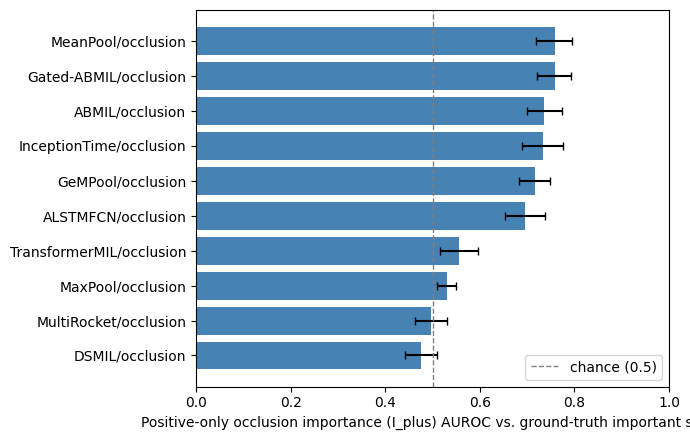

In [19]:
occ_rows = results_df[results_df["signal"].str.endswith("/occlusion")].copy()
occ_rows["mean"] = occ_rows["AUROC [CI]"].apply(lambda s: float(s.split(" [")[0]))
occ_rows["lo"] = occ_rows["AUROC [CI]"].apply(lambda s: float(s.split("[")[1].split(",")[0]))
occ_rows["hi"] = occ_rows["AUROC [CI]"].apply(lambda s: float(s.split(", ")[1].strip("]")))
occ_rows = occ_rows.sort_values("mean")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(occ_rows["signal"], occ_rows["mean"],
        xerr=[occ_rows["mean"] - occ_rows["lo"], occ_rows["hi"] - occ_rows["mean"]],
        color="steelblue", capsize=3)
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1, label="chance (0.5)")
ax.set_xlabel("Positive-only occlusion importance (I_plus) AUROC vs. ground-truth important slices")
ax.set_xlim(0, 1)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(PLOT_PATH, dpi=150)
plt.show()


### One study, three signals: a qualitative sanity check

Per-slice curves for a single ground-truth study: positive-only occlusion
importance (`I_plus`, MeanPool), ABMIL attention, and DSMIL instance score,
with the true important slices shaded -- a visual check that "high AUROC"
corresponds to curves that actually peak inside the shaded region.


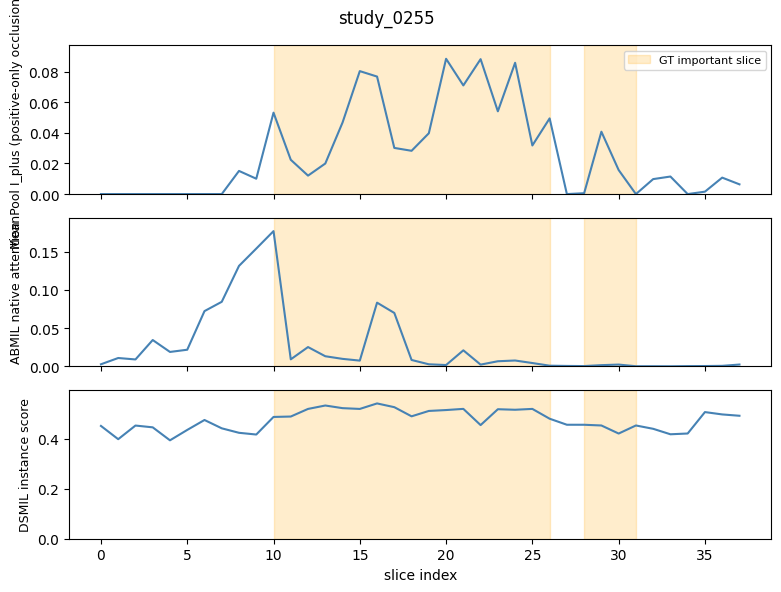

In [20]:
example_id = gt_ids[0]
gt = gt_labels[example_id]
n_slices = len(gt)

occ = positive_only_by_head["MeanPoolClassifier"][example_id]
abmil_attn = xai_results["ABMILClassifier"][example_id]["native_attention"]
dsmil_inst = dsmil_instance_by_id[example_id]

fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
for ax, values, title in zip(
    axes, [occ, abmil_attn, dsmil_inst],
    ["MeanPool I_plus (positive-only occlusion)", "ABMIL native attention", "DSMIL instance score"],
):
    ax.plot(range(n_slices), values, color="steelblue")
    ax.fill_between(range(n_slices), 0, values.max() * 1.1, where=gt.astype(bool),
                    color="orange", alpha=0.2, step="mid", label="GT important slice")
    ax.set_ylabel(title, fontsize=9)
    ax.set_ylim(0, values.max() * 1.1)
axes[0].legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("slice index")
fig.suptitle(f"{example_id}")
fig.tight_layout()
fig.savefig(EXAMPLE_PLOT_PATH, dpi=150)
plt.show()


## Results

Part D's results table (`xai_positive_only_results_table.csv`), sorted by
occlusion AUROC descending, from a completed run on
`hd5_with_mask_vector.h5`'s 50 ground-truth-annotated test studies (all
50/50 valid for every signal -- no study had `K == 0`, `K == N`, or an
all-one-class GT vector). AUROC null (chance) = 0.500; P@K null (mean K/N)
= 0.383.

| Signal | AUROC [CI] | P@K [CI] | null (K/N) | lift [CI] |
|---|---|---|---|---|
| MeanPool/occlusion | 0.759 [0.719, 0.794] | 0.597 [0.531, 0.662] | — | — |
| Gated-ABMIL/occlusion | 0.758 [0.721, 0.793] | 0.643 [0.586, 0.694] | — | — |
| ABMIL/occlusion | 0.736 [0.699, 0.773] | 0.583 [0.514, 0.646] | — | — |
| InceptionTime/occlusion | 0.733 [0.690, 0.775] | 0.588 [0.520, 0.654] | — | — |
| GeMPool/occlusion | 0.716 [0.682, 0.748] | 0.560 [0.501, 0.618] | — | — |
| DSMIL/instance | 0.696 [0.656, 0.735] | 0.557 [0.493, 0.613] | — | — |
| ALSTMFCN/occlusion | 0.696 [0.654, 0.737] | 0.536 [0.473, 0.600] | — | — |
| Gated-ABMIL/attention | 0.657 [0.607, 0.702] | 0.532 [0.478, 0.583] | 0.383 | 1.477 [1.297, 1.678] |
| ABMIL/attention | 0.632 [0.583, 0.678] | 0.504 [0.447, 0.557] | 0.383 | 1.187 [1.036, 1.343] |
| TransformerMIL/occlusion | 0.555 [0.516, 0.597] | 0.411 [0.346, 0.478] | — | — |
| MaxPool/occlusion | 0.530 [0.510, 0.550] | 0.396 [0.346, 0.445] | — | — |
| MultiRocket/occlusion | 0.497 [0.462, 0.531] | 0.361 [0.300, 0.419] | — | — |
| DSMIL/occlusion | 0.476 [0.441, 0.509] | 0.343 [0.279, 0.407] | — | — |
| DSMIL/attention | 0.285 [0.249, 0.320] | 0.221 [0.168, 0.277] | 0.383 | 0.092 [0.034, 0.184] |

**What's different from `xai_localization.ipynb`'s `importance`-based ranking,
empirically, holding HPO/training fixed (same seed, same fitted models --
bag-level test ROC-AUC and every attention/instance number above match the
baseline notebook's run exactly):**

1. **Every occlusion signal's AUROC went up, most substantially.**
   `I_plus` (positive-only) beat `importance` (abs-value) for every single
   head: MeanPool 0.588→0.759 (+0.171), GeMPool 0.464→0.716 (+0.252, the
   largest jump), InceptionTime 0.581→0.733 (+0.152), ABMIL 0.607→0.736
   (+0.129), Gated-ABMIL 0.630→0.758 (+0.128), ALSTMFCN 0.620→0.696 (+0.076),
   TransformerMIL 0.468→0.555 (+0.087), MaxPool 0.427→0.530 (+0.103), DSMIL
   0.349→0.476 (+0.127). MultiRocket is the one exception, essentially flat
   (0.498→0.497). Discarding the negative-signed-delta slices (evidence
   pointing *away* from the ground truth) rather than ranking them alongside
   positive-signed slices by raw magnitude sharpened every head's
   localization signal.
2. **The overall ranking reshuffles: occlusion signals now dominate the top
   of the table.** Under `importance`, the top 3 signals were DSMIL/instance,
   Gated-ABMIL/attention, and ABMIL/attention, with the best occlusion signal
   (Gated-ABMIL/occlusion, 0.630) in 4th place. Under `I_plus`, the top 5 are
   all occlusion signals (MeanPool, Gated-ABMIL, ABMIL, InceptionTime,
   GeMPool, all ≥0.716), and DSMIL/instance drops to 6th.
3. **MaxPool crosses from below chance to (weakly) above it**: 0.427→0.530.
   It's still one of the weaker localizers, but no longer anti-correlated on
   average under this signal.
4. **DSMIL/occlusion and MultiRocket/occlusion remain at/under chance** —
   the dynamic floor-heads check (Step 7 / the cell above) flags exactly
   these two for this run. DSMIL's mean signed importance on GT slices is
   still slightly negative (-0.0002, matching the baseline notebook's
   finding and its architectural explanation: the hard-argmax
   critical-instance mechanism). MultiRocket is oriented correctly
   (+0.0127) but weak — a genuine near-chance localizer under `I_plus`,
   not an anti-correlated one.
5. **Native attention (ABMIL/Gated-ABMIL/DSMIL) and DSMIL/instance are
   numerically identical to the baseline run**, as expected — `I_plus` only
   touches the `.../occlusion` rows.


## Troubleshooting

- **FileNotFoundError on `H5_PATH`:** confirm `hd5_with_mask_vector.h5` is one
  directory up from `notebooks/`, or point `H5_PATH` at your own store.
- **`validate_h5` raises "No samples with split='train'/'test'"**: the store
  needs at least one sample in each of the `train` and `test` splits.
- **No ground-truth studies found (`len(gt_ids) == 0`)**: this notebook needs
  a store where `important_slices` is populated for at least one `test`
  sample; not every `sliceheads` HDF5 store carries these annotations.
- **AUROC / P@K is NaN for a study**: expected when a study has no true
  important slices (`K == 0`) or is fully annotated (`K == N`) -- both are
  excluded from the aggregate, not treated as zero.
- **A study's `I_plus` is all (numerically) zero for a head**: expected when
  every slice in that study has a non-positive `signed_importance` for that
  head -- occluding *no* slice lowered the model's confidence. `epsilon`
  only prevents a division by exactly zero; it doesn't manufacture a
  meaningful ranking out of an all-non-positive study. That study still
  contributes to the AUROC/P@K aggregate like any other (unless `K == 0` or
  `K == N`), it just contributes a near-uninformative ranking.
- **`native_attention` is `None` for a head**: only heads with
  `supports_native_attention = True` under this configuration produce it
  (ABMIL, Gated-ABMIL, DSMIL always; Transformer-MIL only if configured with
  `pooling="attention"`, which this `experiment.yaml` doesn't use).
- **CUDA not available:** the notebook auto-falls-back to CPU; HPO just runs
  slower.
- **Step 5b prints `FAIL` for a head**: that head's `signed_importance` (or
  MIL attention) anti-correlates with the ground truth on average -- this
  also means its `I_plus`-based occlusion ranking will be poor, since
  `I_plus` is derived from the same `signed_importance`. Read "How to read a
  FAIL above" right after Step 5b before assuming it's a bug; it may be a
  real property of that head's trained model, not code.


## Conclusion

In this notebook we ran HPO for every `sliceheads` classification head on the
single existing train/val/test split of `hd5_with_mask_vector.h5`, computed
leave-one-out occlusion importance (`sliceheads.explain.loo_importance`) and
native attention (the MIL family: ABMIL, Gated-ABMIL, DSMIL) for the 50
ground-truth-annotated test studies, and then -- the one deliberate departure
from `xai_localization.ipynb` -- derived a **positive-only** occlusion signal
`I_plus[k] = max(signed_importance[k], 0) / (sum_j max(signed_importance[j], 0)
+ epsilon)` from each head's raw `signed_importance`, and used *that* (not
the package's `importance` field) for every `.../occlusion` row's AUROC and
P@K. Native attention and DSMIL's instance stream were scored unchanged.
Every XAI output was saved through `sliceheads.results.save_results`, plus a
supplementary CSV of `I_plus` per head/study/slice, and every signal was
ranked by AUROC / P@K / attention lift against the true important slices.

To compare against the baseline (`importance`-based) ranking, run
`xai_localization.ipynb` on the same store and seed and compare its
`xai_localization_results_table.csv` against this notebook's
`xai_positive_only_results_table.csv`. To reuse this workflow on your own
annotated store, point `H5_PATH` at a file with `important_slices` populated
and rerun top to bottom.
